In [3]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [4]:
torch.backends.mkldnn.enabled = True

In [5]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [6]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [7]:
model5_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model5_0)
describe(model5_0)

MACs: 7.85 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model5_0.pt
Starting
Epoch 1/60: Train loss = 1.2179, Train accuracy = 0.5701, Test loss = 1.1801, Test accuracy = 0.5866
Epoch 2/60: Train loss = 0.9381, Train accuracy = 0.6729, Test loss = 0.9124, Test accuracy = 0.6885
Epoch 3/60: Train loss = 0.8154, Train accuracy = 0.7142, Test loss = 0.8017, Test accuracy = 0.7183
Epoch 4/60: Train loss = 0.7941, Train accuracy = 0.7247, Test loss = 0.8416, Test accuracy = 0.7138
Epoch 5/60: Train loss = 0.7406, Train accuracy = 0.7435, Test loss = 0.7893, Test accuracy = 0.7344
Epoch 6/60: Train loss = 0.6508, Train accuracy = 0.7756, Test loss = 0.6877, Test accuracy = 0.7668
Epoch 7/60: Train loss = 0.6271, Train accuracy = 0.7773, Test loss = 0.6642, Test accuracy = 0.7746
Epoch 8/60: Train loss = 0.5934, Train accuracy = 0.7923, Test loss = 0.6235, Test accuracy = 0.7905
Epoch 9/60: Train loss = 0.6070, Train accuracy = 0.7904, Test loss = 0.6232, Test accuracy = 0.7912
Epoch 10/60: Train loss = 0.5478

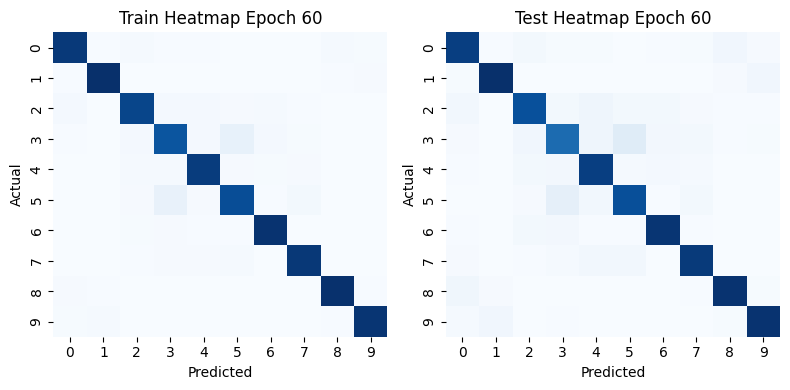

<Figure size 1200x600 with 0 Axes>

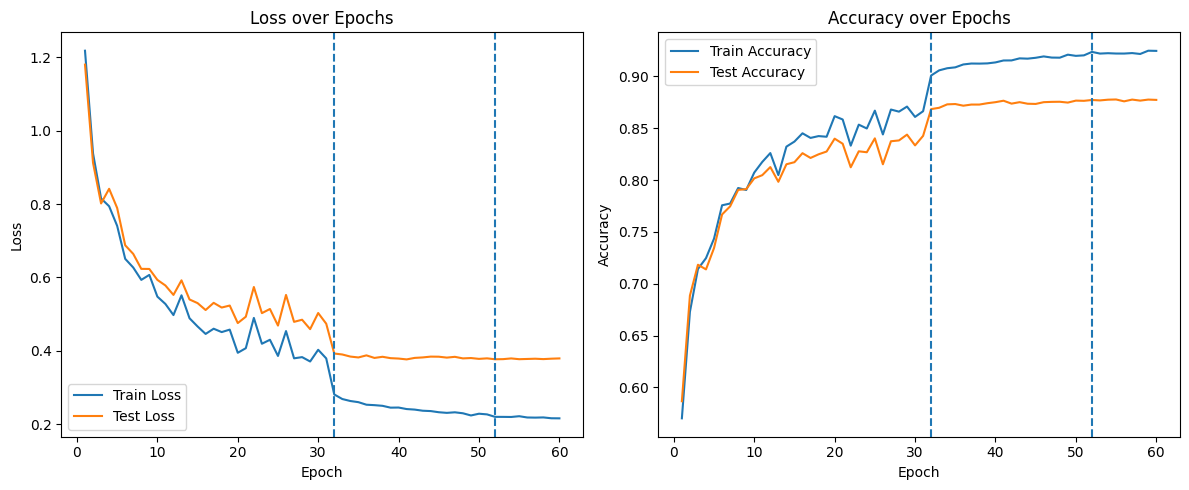

In [8]:
trainf32(model5_0,"model_weights/model5_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model5_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model5_1)
describe(model5_1)

MACs: 7.85 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model5_1.pt
Starting
Epoch 1/60: Train loss = 1.0485, Train accuracy = 0.6289, Test loss = 1.0287, Test accuracy = 0.6434
Epoch 2/60: Train loss = 0.8801, Train accuracy = 0.6929, Test loss = 0.8588, Test accuracy = 0.7016
Epoch 3/60: Train loss = 0.7625, Train accuracy = 0.7371, Test loss = 0.7860, Test accuracy = 0.7345
Epoch 4/60: Train loss = 0.7058, Train accuracy = 0.7580, Test loss = 0.6885, Test accuracy = 0.7647
Epoch 5/60: Train loss = 0.6722, Train accuracy = 0.7710, Test loss = 0.6843, Test accuracy = 0.7727
Epoch 6/60: Train loss = 0.6257, Train accuracy = 0.7820, Test loss = 0.6280, Test accuracy = 0.7891
Epoch 7/60: Train loss = 0.5652, Train accuracy = 0.8075, Test loss = 0.5946, Test accuracy = 0.8040
Epoch 8/60: Train loss = 0.5488, Train accuracy = 0.8101, Test loss = 0.5734, Test accuracy = 0.8062
Epoch 9/60: Train loss = 0.5302, Train accuracy = 0.8179, Test loss = 0.5670, Test accuracy = 0.8065
Epoch 10/60: Train loss = 0.5409

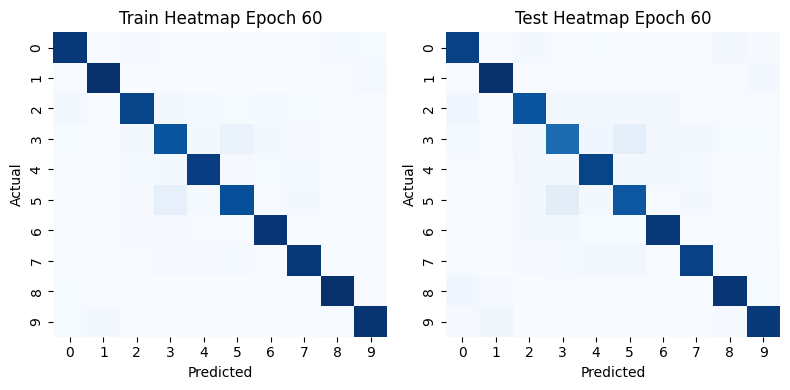

<Figure size 1200x600 with 0 Axes>

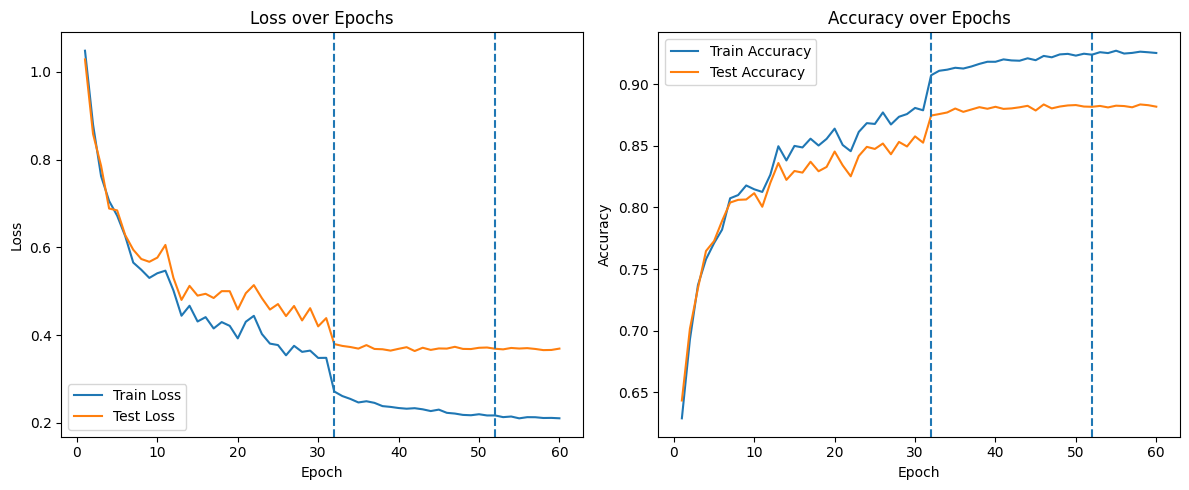

In [10]:
trainf32(model5_1,"model_weights/model5_1.pt",criterion,train_dataset,val_dataset, batch_size=64)